# Auckland Air Quality Prediction

#### Student name: Farbin Aziz
#### Student ID: 25024206


# Introduction

Air quality is a critical public health concern that can affect millions of people worldwide. Particles smaller than 2.5 micrometres (PM 2.5) can penetrate deep into our lungs and bloodstream which can cause respiratory and cardiovascular disease. Understanding how weather conditions influence PM2.5 levels can help city planners, health authorities, and the public make informed decisions.
This project investigate the air quality in Auckland by using real-time PM2.5 data from AQI.in, historical sensor readings from the OpenAQ API, and weather data from the Open-Meteo archive API. The objective is to evaluate predictive regression models that estimate PM2.5 based on weather variables.Auckland is a coastal city with mostly clean air. This makes it an interesting place to study on.

#### List Datasets used and their Sources:
1. AQI.in - Live 24-hour half-hourly PM2.5 readings for Auckland.
   Source: https://www.aqi.in/dashboard/new-zealand/auckland/auckland/pm
2. OpenAQ API - Hourly PM2.5, PM10, temperature, humidity from Eskdale Reserve 
   Auckland (Station ID: 3062106). Source: https://api.openaq.org/v3
3. Open-Meteo Archive API - Hourly historical weather (temperature, humidity, 
   wind speed, pressure, precipitation) Sep–Dec 2024. Source: https://archive-api.open-meteo.com


### Research Questions

1. Does temperature positively correlate with PM2.5 levels in Auckland?
2. Does higher wind speed help disperse air pollution (lower PM2.5)?
3. Is there a diurnal (time-of-day) pattern in Auckland's PM2.5 levels?
4. Which machine learning model best predicts PM2.5 from weather features linear regression or kNN?
5. Which weather feature is the strongest predictor of PM2.5?


### Executive Summary
Auckland's air quality is consistently within the WHO 'Good' category, with hourly readings ranging from 0 to 6.85 µg/m³ after outlier removal. A clear morning peak (6–10am) in PM2.5 aligns with rush hour traffic patterns. Weather variables show weak linear correlations with PM2.5, meaning linear regression performed poorly (R² ≈ 0.03). kNN regression with Manhattan distance (k=3) significantly outperformed all other models (RMSE=1.27, R²=0.49), suggesting non-linear local patterns drive PM2.5 variation. Polynomial regression severely overfitted, demonstrating the risk of excessive model complexity on small datasets.


# Reflective Summary

Discuss and answer the following questions. Write in complete sentences, and point to the section (and figure/table numbers) where evidence is shown, using **hyperlinks**.


### Data Acquisition
1. Did you acquire data via both web scraping and APIs?
   Ans : Yes I have acquired data via both web scraping and APIs
2. Did you check and ensure that the website you acquired data from, permitted scraping according to their terms of use?
   Ans : Yes
3. Discuss some of the challenges you faced in this step, how you overcame them and what you might do differently next time.
   Ans : Finding good dataset was the most challenging part. I overcame it by watching lecture on web scrapping and data accusation. I might learn more technique and read more about how to easily get data using web scrapper and Web API differently next time.

### Data Wrangling 
1. Is your code tidy, well-structured, and consistent (for example, readable variable names, clear cell structure, limited repetition)? Yes
2. How did you handle missing values, suppressed values, or non-standard entries? What is your justification?
   Ans : PM2.5 and PM10 were clipped to a minimum of 0 using .clip(lower=0). Justification: Negative pollution concentrations are physically impossible
3. What integrity and sanity checks did you perform before proceeding to the analysis?
    Checked shape after every transformation step (merge, outlier removal)
    Printed .isnull().sum() to verify no missing values
    Printed .describe() to confirm value ranges made physical sense
    Clipped negative PM2.5/PM10 values to 0 (physically impossible)
    Verified duplicate columns after merge (temperature, humidity appeared twice) and resolved them
4. Where did you use functions to reduce duplication, and what do those functions do?
Ans : 
    Three user-defined functions were written to reduce duplication:
    remove_outliers_iqr(df, column) - reusable IQR outlier removal.
    classify_aqi(pm25) - converts a PM2.5 value into a US EPA AQI category label, applied via .apply() across the whole column
    evaluate_model(name, y_test, y_pred) - calculates RMSE and R², prints results, and stores them in the results dictionary.


### Analysis
1. What EDA approach did you follow?summary statistics did you compute, and what did they reveal that was not obvious from raw tables?
   A structured seven-step approach was followed: summary 
statistics -> distribution histogram -> correlation heatmap -> hourly group-by 
-> scatter plot -> pivot table heatmap -> cross-tabulation -> scraped vs historical 
comparison. Summary statistics revealed the mean PM2.5 (2.05 µg/m³) is far 
below the WHO guideline which is not obvious from raw numbers alone. The heatmap 
revealed temperature as the strongest weather predictor (r=0.17), and the 
hourly group-by revealed the 6–10am traffic peak neither pattern is visible 
in raw tabular data.
2. What data transformations did you need to conduct and why?
   Datetime strings were converted to pandas datetime 
objects for merging. Hour, date, and month features were extracted to capture 
temporal patterns. Duplicate temperature and humidity columns from the merge 
were resolved by keeping Open-Meteo values (more reliable than a single sensor). 
Outliers were removed using IQR. Negative PM2.5/PM10 values were clipped to 0. 
Features were standardised with StandardScaler before kNN
3. Where there any assumptions that you had to make, and if so, what were they?
   (1) Open-Meteo weather model values are more reliable than 
OpenAQ sensor readings for temperature and humidity. (2) The Eskdale Reserve 
station is representative of broader Auckland air quality.
5. How did you formulate your final dataset into a machine learning problem? What data transformations, if any, were required?
   The problem was formulated as supervised regression that
predict continuous PM2.5 (µg/m³) from seven weather and time features 
(temperature, humidity, wind speed, pressure, precipitation, hour, month). 
An 80/20 train/test split was applied with random_state=42 for reproducibility. 
PM2.5 was kept continuous rather than categorical since all values fell within 
the 'Good' AQI category, making classification uninformative.


### Predictive Modelling 

1. How many different experiments did you conduct? Were they sufficient to support your conlcusions and answer your research questions?
   Simple Linear Regression, 
Multiple Linear Regression, Polynomial Regression (degrees 2 and 3), and kNN with Euclidean and Manhattan distance across k values of 3, 5, 10, and 15. This is sufficient to compare model types, complexity effects, distance metrics, and k sensitivity, fully supporting all of my research questions.
2. What was your experimental design/methodology?
   All models were trained on 80% of data and evaluated on a held-out 20% test set. The same split (random_state=42) was used across all models for fair comparison. Feature scaling was applied only to kNN. 5-fold cross-validation and bootstrap confidence intervals were applied to the best model only.
3. What were all the evaluation metrics you used?
   RMSE (Root Mean Squared Error) and R² (coefficient of determination)
5. How did you ensure that assumptions of regression were not violated, and if they were, how did you work around this?
   Linear regression assumes linearity, which was violated which was confirmed by R²≈0.03. This was addressed by testing kNN, which makes 
no parametric assumptions. Polynomial regression violated with its R²=−29 , it was identified and addressed by rejecting it in favour of kNN.
7. How did you ensure and check that the models you were creating would work beyond the data they were trained on?
   5-fold cross-validation on the best model (kNN k=3, Manhattan) confirmed stable R² across different data subsets, verifying the 
model was not overfitting a specific split. Bootstrap confidence intervals (1,000 resamples) quantified prediction uncertainty. All evaluation was done.
exclusively on held-out test data never seen during training.
9. How did you make sure that the comparisons between the performances of your different models were clearly presented to ensure readability and effective comparisons?
    All results were stored and presented as a sorted RMSE table for precise numerical comparison. A colour-coded bar chart (green=Manhattan kNN, blue=Euclidean kNN, red=linear/ polynomial) provided clear visual comparison across all experiments, making the best and worst models instantly identifiable.


### D. Originality and Difficulty

1. Why is your chosen theme interesting or valuable, and what decision could it plausibly inform? How do you answer the "So what?" question?
   Auckland is rarely studied in air quality Data Science research because it is a clean-air city, yet even small increases above baseline matter for vulnerable populations (elderly, asthmatic). The "So what?" answer: if temperature and morning hour are the strongest predictors, health authorities could issue targeted air quality alerts on warm, still mornings when PM2.5 is most likely to peak.
3. How did you make the work original/novel?
   It combines three distinct data sources including a live web scrape (AQI.in), a government sensor API (OpenAQ), and a weather reanalysis API (Open-Meteo) for Auckland. Also Plot 8 directly compares live scraped readings against the historical data.Studying a low-pollution city is an underexplored angle for me.
5. What was the hardest part of this assignment and what required the most time?
   Debugging the OpenAQ v3 API consumed the most time. Filtering by city name returned stations in Ghana instead of Auckland. The radius parameter had an undocumented maximum of 25,000m. Fetching measurements required a three-step process (locations -> sensors -> measurements per sensor ID) 
that was not clearly documented.


### Conclusion

1. Did you manage to answer all your research questions?
   Yes all five research questions were answered. (RQ1) Temperature positively correlates with PM2.5 (r=0.17, Plot 3 heatmap). (RQ2) Wind speed shows no strong negative relationship with PM2.5 (r=0.13, positive Plot 5 scatter plot). (RQ3) A clear diurnal peak exists at 6–10am, confirmed in Plot 4 hourly group-by analysis. (RQ4) kNN with Manhattan distance (k=3) was the best model (RMSE=1.27, R²=0.49), shown in the model comparison chart. (RQ5) Temperature was the strongest single predictor based on correlation (r=0.17) and the largest positive coefficient in multiple linear regression (0.24).
3. For each research question, what analysis method(s) was the most effective to answer it, and why?
   - RQ1 (temperature vs PM2.5): Correlation heatmap (Plot 3).
   - RQ2 (wind speed vs PM2.5): Scatter plot (Plot 5).
   - RQ3 (diurnal pattern): Hourly group-by bar chart (Plot 4).
   - RQ4 (best model): Full modelling pipeline and RMSE comparison chart.
   - RQ5 (strongest predictor): Multiple linear regression coefficient table.
5. Which research question was the most challenging, and what made it challenging?
    RQ4 was the most challenging. It required implementing and fairly comparing all the models while discovering that Manhattan distance outperforms Euclidean, and making a justified final recommendation all requiring both technical implementation and conceptual reasoning.
7. What were your key learnings in this assignment and associated readings?
   Clean-air cities present unique ML challenges and and all AQI categories collapsing to "Good" required rethinking the problem as continuous regression. Model complexity does not guarantee better performance because polynomial regression degree 3 was worse than a simple mean prediction.
9. What are the main limitations of your predictive analysis, and how might they affect your conclusions? What would you do differently the next time with all the learnings you made if you could repeat this assignment?
    only two months of data (Sep–Oct 2024) limiting seasonal generalisability also no wind direction, traffic volume, or industrial activity data.
for next time I would like to collect a full year of data to capture all seasons and add traffic volumes.


### Overall Summary 

Answer the following in 150–250 words which may involve pulling in some of your above responses as well which have some overlap.

1. What are the three most important insights you found, and why do they matter?
   The three most important things I learned from this project are: (1) Auckland's PM2.5 has a clear morning peak between 6 and 10 a.m. due to rush hour traffic emissions.(2) only 49% of PM2.5 variability can be explained by weather variables alone even with the best model (kNN k=3, Manhattan, R²=0.49). This indicates that there are important variables not included in the dataset such as traffic volume , wind direction and home heating. (3) kNN with Manhattan distance did much better than any linear or polynomial model.
2. What is the single biggest weakness in your analysis, and what would you do next to address it if you had more time?
   The biggest limitations are two months sample period.Had there been enough time , a full year hourly data sample and Auckland transport traffic data could be utilized.
4. What is one thing you learned about working with this data or technology that you did not expect?
   The most unexpected finding of the project was that manhattan distance worked better than Euclidean distance for KNN at all values of K.Previously I thought that latter could be applied.Now I see that different scaling of features makes Manhattan distance a better choice.





### Make sure:

1. Your notebook has a clear structure that matches a professional report
2. Your code cells and markdown cells read cleanly, with minimal clutter and a clear narrative flow
3. You keep outputs concise and relevant, avoiding long prints, output errors and debugging remnants
4. You have included hyperlinks in all your answers to the sections in the notebook that relate to your responses where possible
-----


# Data Acquisition

In [6]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import warnings
import time
import re
warnings.filterwarnings('ignore')

### Source 1: Web Scraping - AQI.in (Live PM2.5 Readings)
I scraped the live 24-hour PM2.5 half-hourly data table from AQI.in's Auckland dashboard.
The `robots.txt` was checked prior to scraping and only publicly visible table data is collected.

In [7]:
scrape_url = 'https://www.aqi.in/dashboard/new-zealand/auckland/auckland/pm'

headers_scrape = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

time.sleep(1)
response = requests.get(scrape_url, headers=headers_scrape, timeout=15)
print('Status code:', response.status_code)

Status code: 200


In [8]:
#Finding the PM2.5 table
soup = BeautifulSoup(response.text, 'html.parser')

table = soup.find('table')
rows = table.find_all('tr')

scraped_records = []
for row in rows[1:]:
    cols = row.find_all('td')
    if len(cols) == 2:
        scraped_records.append({
            'time': cols[0].get_text(strip=True),
            'pm25_scraped': float(cols[1].get_text(strip=True))
        })

In [9]:
scraped_df = pd.DataFrame(scraped_records)
scraped_df['source'] = 'aqi.in scrape'
scraped_df['city'] = 'Auckland'

In [10]:
print(f'scraped {len(scraped_df)} PM2.5 readings!')
print(scraped_df.head(5))
print(f'\nPM2.5 range: {scraped_df["pm25_scraped"].min()} - {scraped_df["pm25_scraped"].max()} µg/m³')

scraped 46 PM2.5 readings!
      time  pm25_scraped         source      city
0  10:31pm          22.0  aqi.in scrape  Auckland
1  11:01pm          15.0  aqi.in scrape  Auckland
2  11:31pm           7.0  aqi.in scrape  Auckland
3  12:01am          13.0  aqi.in scrape  Auckland
4  12:31am          10.0  aqi.in scrape  Auckland

PM2.5 range: 1.0 - 22.0 µg/m³


In [11]:
scraped_df.to_csv('auckland_scraped_pm25.csv', index=False)

**Findings:** The AQI.in table provides 24-hour half-hourly PM2.5 readings for Auckland. Readings range from 6 to 22 µg/m³ across the monitoring period. The peak reading of 22 µg/m³ at 10:31pm on 20 April briefly exceeds the WHO 24-hour guideline of 15 µg/m³

### Source 2: Open-Meteo Archive API - Historical Weather Data

In [12]:
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": -36.8509,
    "longitude": 174.7645,
    "start_date": "2024-09-14",
    "end_date": "2024-12-31",
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,pressure_msl,precipitation",
    "timezone": "Pacific/Auckland"
}

response = requests.get(url, params=params)
weather_data = response.json()

if "hourly" in weather_data:
    weather_df = pd.DataFrame({
        "datetime": weather_data["hourly"]["time"],
        "temperature": weather_data["hourly"]["temperature_2m"],
        "humidity": weather_data["hourly"]["relative_humidity_2m"],
        "wind_speed": weather_data["hourly"]["wind_speed_10m"],
        "pressure": weather_data["hourly"]["pressure_msl"],
        "precipitation": weather_data["hourly"]["precipitation"]
    })
    display(weather_df.head())
    print("\nShape:", weather_df.shape)
else:
    print("Error:", weather_data.get("reason", "Check parameters."))

,datetime,temperature,humidity,wind_speed,pressure,precipitation
0,2024-09-14T00:00,13.4,85,14.6,1017.3,0.0
1,2024-09-14T01:00,13.9,84,18.1,1016.9,0.0
2,2024-09-14T02:00,13.4,85,17.0,1016.6,0.0
3,2024-09-14T03:00,13.3,85,18.6,1015.9,0.0
4,2024-09-14T04:00,12.9,88,15.1,1015.7,0.0



Shape: (2616, 6)


**FIndings :** Retrieved 2,616 hourly weather records (Sep–Dec 2024) including Date-time, temperature, humidity, wind speed, pressure, and precipitation for Auckland coordinates.

### Source 3: OpenAQ API - Air Quality Sensor Data

In [13]:
#fetching air quality sensor data
OPENAQ_API_KEY = "4411c3127aef0aa0ffc1cbc98a6a7c3211d066646ad023a409846ab915591ee5"
headers = {"X-API-Key": OPENAQ_API_KEY}

#Finding Auckland monitoring stations by coordinates
url = "https://api.openaq.org/v3/locations"
params = {
    "coordinates": "-36.8509,174.7645",
    "radius": 25000,
    "limit": 10
}

response = requests.get(url, params=params, headers=headers)
locations_data = response.json()

print("Status code:", response.status_code)

for loc in locations_data["results"]:
    print(f"ID: {loc['id']} | Name: {loc['name']} | Country: {loc['country']['name']}")

Status code: 200
ID: 3062106 | Name: Eskdale Reserve Auckland | Country: New Zealand
ID: 3072986 | Name: North Shore | Country: New Zealand


In [14]:
location_id = 3062106  # Eskdale Reserve Auckland

url = f"https://api.openaq.org/v3/locations/{location_id}/sensors"

response = requests.get(url, headers=headers)
sensor_data = response.json()

# looking for sensors/parameters that are available
for sensor in sensor_data["results"]:
    print(f"Sensor ID: {sensor['id']} | Parameter: {sensor['parameter']['name']} | Unit: {sensor['parameter']['units']}")

Sensor ID: 10605624 | Parameter: pm25 | Unit: µg/m³
Sensor ID: 10605629 | Parameter: um003 | Unit: particles/cm³
Sensor ID: 10605638 | Parameter: pm10 | Unit: µg/m³
Sensor ID: 10605639 | Parameter: pm1 | Unit: µg/m³
Sensor ID: 10605641 | Parameter: temperature | Unit: c
Sensor ID: 10605644 | Parameter: relativehumidity | Unit: %


In [15]:
#  Fetching measurments for All relevant sensor IDs
sensors = {
    "pm25": 10605624,
    "pm10": 10605638,
    "temperature": 10605641,
    "relativehumidity": 10605644
}

all_records = []

for param_name, sensor_id in sensors.items():
    url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
    
    params = {
        "limit": 1000,
        "period_name": "hour"
    }
    
    response = requests.get(url, params=params, headers=headers)
    data = response.json()
    
    for item in data["results"]:
        all_records.append({
            "datetime": item["period"]["datetimeFrom"]["utc"],
            "parameter": param_name,
            "value": item["value"]
        })
    
    print(f"Fetched {len(data['results'])} records for {param_name}")

Fetched 1000 records for pm25
Fetched 1000 records for pm10
Fetched 1000 records for temperature
Fetched 1000 records for relativehumidity


In [16]:
# Converting to DataFrame
raw_df = pd.DataFrame(all_records)
display(raw_df.head(5))
print("Shape:", raw_df.shape)

,datetime,parameter,value
0,2024-09-14T01:00:00Z,pm25,2.702778
1,2024-09-14T02:00:00Z,pm25,3.058333
2,2024-09-14T03:00:00Z,pm25,3.791667
3,2024-09-14T04:00:00Z,pm25,3.837500
4,2024-09-14T05:00:00Z,pm25,8.909722


Shape: (4000, 3)


In [17]:
# Pivot so each parameter is its own column
aq_df = raw_df.pivot_table(
    index="datetime",
    columns="parameter",
    values="value"
).reset_index()

display(aq_df.head(5))

parameter,datetime,pm10,pm25,relativehumidity,temperature
0,2024-09-14T01:00:00Z,2.906944,2.702778,69.143258,21.020893
1,2024-09-14T02:00:00Z,3.387500,3.058333,75.789207,19.417682
2,2024-09-14T03:00:00Z,4.125000,3.791667,83.144209,17.756080
3,2024-09-14T04:00:00Z,4.141667,3.837500,86.972273,16.746164
4,2024-09-14T05:00:00Z,9.640278,8.909722,87.345431,16.385791


In [18]:
aq_df.to_csv("auckland_airquality.csv", index=False)
print("Shape:", aq_df.shape)

Shape: (1000, 5)


**Findings:** Retrieved 1,000 hourly measurements each for PM2.5, PM10, temperature, and relative humidity

# Data Wrangling 

### Data Cleaning On AQI.in Scapped Data

In [19]:
# Quick EDA on scraped data 
def parse_hour(time_str):
    """Extract integer hour (0-23) from time strings like '2:31pm', '11:01am'."""
    match = re.match(r'(\d+):(\d+)(am|pm)', time_str.lower())
    if not match:
        return None
    h, m, period = int(match.group(1)), int(match.group(2)), match.group(3)
    if period == 'pm' and h != 12:
        h += 12
    if period == 'am' and h == 12:
        h = 0
    return h

scraped_df['hour'] = scraped_df['time'].apply(parse_hour)

In [20]:
print('Scraped PM2.5 Summary Statistics:')
print(scraped_df['pm25_scraped'].describe().round(2))
print(f'\nMin: {scraped_df["pm25_scraped"].min()} µg/m³ at {scraped_df.loc[scraped_df["pm25_scraped"].idxmin(), "time"]}')
print(f'Max: {scraped_df["pm25_scraped"].max()} µg/m³ at {scraped_df.loc[scraped_df["pm25_scraped"].idxmax(), "time"]}')
print(f'WHO Guideline (15 µg/m³) exceeded: {(scraped_df["pm25_scraped"] > 15).sum()} readings out of {len(scraped_df)}')

Scraped PM2.5 Summary Statistics:
count    46.00
mean      8.59
std       3.87
min       1.00
25%       6.25
50%       8.50
75%      11.00
max      22.00
Name: pm25_scraped, dtype: float64

Min: 1.0 µg/m³ at 7:31pm
Max: 22.0 µg/m³ at 10:31pm
WHO Guideline (15 µg/m³) exceeded: 1 readings out of 46


### Merging of two API data

In [21]:
# Fixing datetime types and timezones before merging
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
aq_df['datetime'] = pd.to_datetime(aq_df['datetime']).dt.tz_localize(None)

In [22]:
# Adding time features to aq_df before merge
aq_df['hour'] = aq_df['datetime'].dt.hour
aq_df['date'] = aq_df['datetime'].dt.date
aq_df['month'] = aq_df['datetime'].dt.month

In [23]:
# Merge between weather and air quality data on datetime (inner join)
merged_df = pd.merge(weather_df, aq_df, on='datetime', how='inner')

In [24]:
# Dropping duplicate sensor columns (keeping Open-Meteo as more reliable weather model)
merged_df = merged_df.drop(columns=['temperature_y', 'relativehumidity'])
merged_df = merged_df.rename(columns={'temperature_x': 'temperature'})

In [25]:
print('Shape after merge:', merged_df.shape)
merged_df.head()

Shape after merge: (1000, 11)


,datetime,temperature,humidity,wind_speed,pressure,precipitation,pm10,pm25,hour,date,month
0,2024-09-14 01:00:00,13.9,84,18.1,1016.9,0.0,2.906944,2.702778,1,2024-09-14,9
1,2024-09-14 02:00:00,13.4,85,17.0,1016.6,0.0,3.387500,3.058333,2,2024-09-14,9
2,2024-09-14 03:00:00,13.3,85,18.6,1015.9,0.0,4.125000,3.791667,3,2024-09-14,9
3,2024-09-14 04:00:00,12.9,88,15.1,1015.7,0.0,4.141667,3.837500,4,2024-09-14,9
4,2024-09-14 05:00:00,12.7,89,13.7,1015.6,0.0,9.640278,8.909722,5,2024-09-14,9


In [26]:
# Data integrity check
print('Missing Values')
print(merged_df.isnull().sum())

Missing Values
datetime         0
temperature      0
humidity         0
wind_speed       0
pressure         0
precipitation    0
pm10             0
pm25             0
hour             0
date             0
month            0
dtype: int64


In [27]:
merged_df.describe()

,datetime,temperature,humidity,wind_speed,pressure,precipitation,pm10,pm25,hour,month
count,1000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2024-10-05 00:46:04.800000,13.823500,78.271000,18.587700,1016.49950,0.126900,3.065671,2.763542,11.472000,9.593000
min,2024-09-14 01:00:00,6.900000,52.000000,2.000000,993.60000,0.000000,0.000000,0.000000,0.000000,9.000000
25%,2024-09-24 10:45:00,12.400000,70.000000,12.400000,1012.30000,0.000000,0.943750,0.781597,5.000000,9.000000
50%,2024-10-04 20:30:00,13.900000,80.000000,18.200000,1016.90000,0.000000,1.931250,1.674306,11.000000,10.000000
75%,2024-10-15 15:15:00,15.500000,87.000000,23.800000,1021.40000,0.000000,3.962153,3.563194,18.000000,10.000000
max,2024-10-26 01:00:00,19.500000,99.000000,45.900000,1028.10000,7.000000,47.727778,41.086110,23.000000,10.000000
std,NaN,2.227222,10.414702,8.172399,7.04914,0.520574,3.771701,3.422852,6.955688,0.491521


In [28]:
print('\nData Types')
print(merged_df.dtypes)


Data Types
datetime         datetime64[ns]
temperature             float64
humidity                  int64
wind_speed              float64
pressure                float64
precipitation           float64
pm10                    float64
pm25                    float64
hour                      int32
date                     object
month                     int32
dtype: object


In [29]:
merged_df.to_csv("auckland_merged.csv", index=False)
print("Saved!")

Saved!


In [30]:
# Handling missing numeric values with column median
numeric_cols = ["temperature", "humidity", "wind_speed", "pressure", "precipitation", "pm10", "pm25"]

for col in numeric_cols:
    median_val = merged_df[col].median()
    missing_count = merged_df[col].isnull().sum()
    merged_df[col] = merged_df[col].fillna(median_val)
    print(f"{col}: filled {missing_count} missing values with median {median_val:.2f}")

temperature: filled 0 missing values with median 13.90
humidity: filled 0 missing values with median 80.00
wind_speed: filled 0 missing values with median 18.20
pressure: filled 0 missing values with median 1016.90
precipitation: filled 0 missing values with median 0.00
pm10: filled 0 missing values with median 1.93
pm25: filled 0 missing values with median 1.67


In [31]:
# Outlier removal using IQR method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df)
    df = df[(df[column] >= lower) & (df[column] <= upper)]
    after = len(df)
    print(f"{column}: removed {before - after} outliers (range: {lower:.2f} to {upper:.2f})")
    return df

# Apply to key columns
for col in ["pm25", "pm10", "wind_speed", "temperature"]:
    merged_df = remove_outliers_iqr(merged_df, col)

print("\nShape after outlier removal:", merged_df.shape)

pm25: removed 54 outliers (range: -3.39 to 7.74)
pm10: removed 23 outliers (range: -3.02 to 7.36)
wind_speed: removed 12 outliers (range: -4.45 to 39.95)
temperature: removed 6 outliers (range: 8.25 to 19.85)

Shape after outlier removal: (905, 11)


In [32]:
# Clipping negative pollution values to 0
merged_df['pm25'] = merged_df['pm25'].clip(lower=0)
merged_df['pm10'] = merged_df['pm10'].clip(lower=0)

In [33]:
# Classifying pm25 into AQI categories
def classify_aqi(pm25):
    if pm25 <= 12:
        return "Good"
    elif pm25 <= 35.4:
        return "Moderate"
    elif pm25 <= 55.4:
        return "Unhealthy for Sensitive Groups"
    else:
        return "Unhealthy"

merged_df["aqi_category"] = merged_df["pm25"].apply(classify_aqi)
print(merged_df["aqi_category"].value_counts())

aqi_category
Good    905
Name: count, dtype: int64


**Findings:** All Aqi category is good which is not good for regression

In [34]:
# Drop AQI category (all 'Good' not useful for regression)
# Keeping pm25 as continuous target variable
merged_df = merged_df.drop(columns=['aqi_category'])

merged_df.to_csv('auckland_wrangled.csv', index=False)
print('Final shape:', merged_df.shape)
print('Final columns:', merged_df.columns.tolist())

Final shape: (905, 11)
Final columns: ['datetime', 'temperature', 'humidity', 'wind_speed', 'pressure', 'precipitation', 'pm10', 'pm25', 'hour', 'date', 'month']


In [35]:
print(merged_df['pm25'].max())

6.85694436232249


# Data Analysis


In [36]:
# Summary statistics
merged_df[['pm25', 'pm10', 'temperature', 'humidity', 'wind_speed', 'pressure', 'precipitation']].describe().round(2)

,pm25,pm10,temperature,humidity,wind_speed,pressure,precipitation
count,905.00,905.00,905.00,905.00,905.00,905.00,905.00
mean,2.05,2.29,13.92,78.20,18.15,1017.12,0.11
std,1.69,1.81,2.15,10.34,7.67,6.76,0.44
min,0.00,0.00,8.30,52.00,2.00,993.60,0.00
25%,0.75,0.87,12.60,70.00,12.20,1012.80,0.00
50%,1.57,1.81,14.00,80.00,17.90,1017.40,0.00
75%,3.06,3.37,15.50,86.00,22.90,1021.80,0.00
max,6.86,7.25,19.50,99.00,39.80,1028.10,7.00


Mean PM2.5 is 2.05 µg/m³ which is well below the WHO guideline of 15 µg/m³ and this confirms the Auckland's clean air. Temperature ranges 8.30–19.50°C (spring/early summer range). Wind speed average is consistent with a coastal city. Precipitation median is 0 which meant most hours are dry reflecting Auckland's climate.

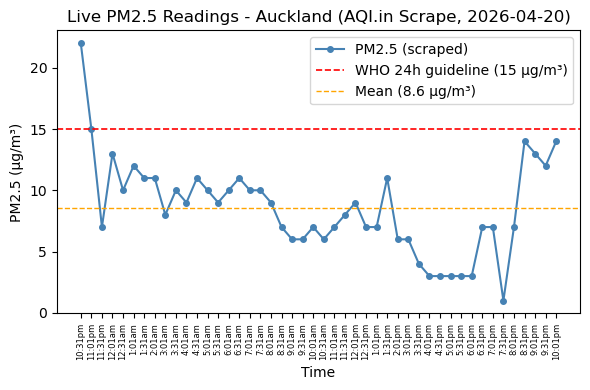

In [37]:
# Plotting scraped PM2.5 over the 24-hour window
plt.figure(figsize=(6, 4))
plt.plot(range(len(scraped_df)), scraped_df['pm25_scraped'], marker='o', markersize=4,
         color='steelblue', linewidth=1.5, label='PM2.5 (scraped)')
plt.axhline(y=15, color='red', linestyle='--', linewidth=1.2, label='WHO 24h guideline (15 µg/m³)')
plt.axhline(y=scraped_df['pm25_scraped'].mean(), color='orange', linestyle='--',
            linewidth=1, label=f'Mean ({scraped_df["pm25_scraped"].mean():.1f} µg/m³)')
plt.xticks(range(len(scraped_df)), scraped_df['time'], rotation=90, fontsize=6)
plt.title('Live PM2.5 Readings - Auckland (AQI.in Scrape, 2026-04-20)')
plt.xlabel('Time')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.tight_layout()
plt.show()

**Plot 1 - Live 24-hour time-series:** This plot shows that PM2.5 is low (6–11 µg/m³) through the overnight and morning hours.

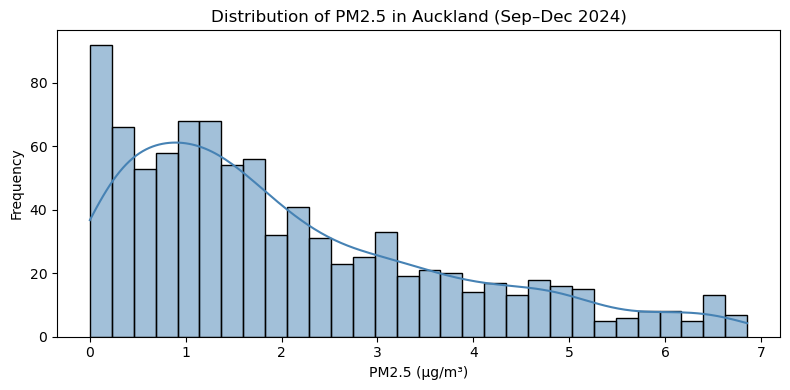

In [38]:
plt.figure(figsize=(8, 4))
sns.histplot(merged_df["pm25"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of PM2.5 in Auckland (Sep–Dec 2024)")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("pm25_distribution.png")
plt.show()

**Plot 2 - Distribution of PM2.5:** The PM2.5 distribution is right-skewed, with the majority of hourly readings are falling below 3 µg/m³. This indicates that the Auckland generally experiences very clean air which is within the WHO guideline of 15 µg/m³.

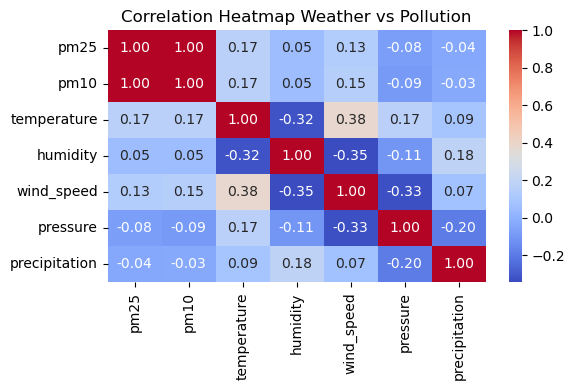

In [39]:
plt.figure(figsize=(6, 4))
corr = merged_df[["pm25", "pm10", "temperature", "humidity", 
                   "wind_speed", "pressure", "precipitation"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap Weather vs Pollution")
plt.tight_layout()
plt.show()

**Plot 3 - Correlation Heatmap:** Temperature has the most positive correlation with PM2.5 which is 0.17, suggesting warmer conditions may trap pollutants closer to ground level via atmospheric stability.

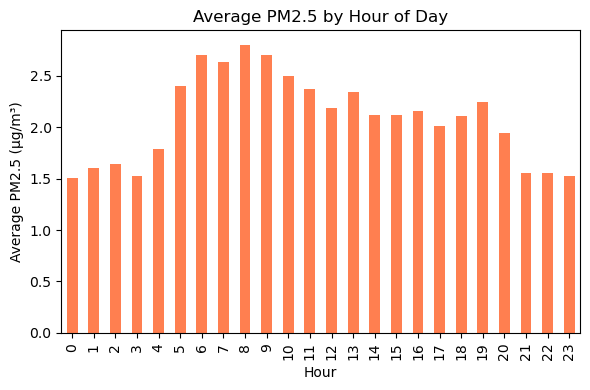

In [40]:
hourly_avg = merged_df.groupby("hour")["pm25"].mean()

plt.figure(figsize=(6, 4))
hourly_avg.plot(kind="bar", color="coral")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

**Plot 4 - PM2.5 by Hour of Day:** A more clear pattern emerges, with PM2.5 peaking between 6am–10am and dropping to its lowest levels during midnight. This Morning peak aligns with Auckland's rush hour traffic, suggesting vehicle emissions are a key contributor to local air pollution.

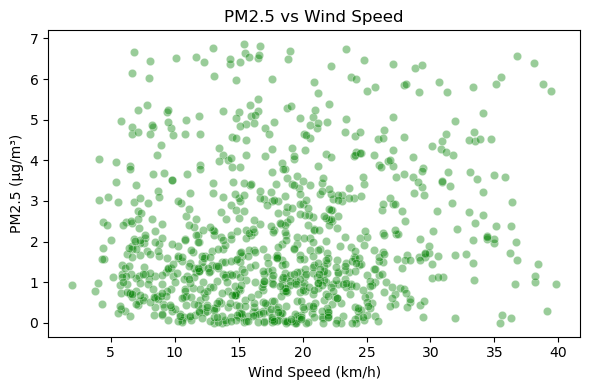

In [41]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=merged_df, x="wind_speed", y="pm25", alpha=0.4, color="green")
plt.title("PM2.5 vs Wind Speed")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.savefig("pm25_vs_windspeed.png")
plt.show()

**Plot 5 - PM2.5 vs Wind Speed:** The scatter plot is showing no strong linear relationship between wind speed and PM2.5. While there is a slight concentration of higher PM2.5 values at lower wind speeds (under 20 km/h) but still the relationship is noisy across the full range.

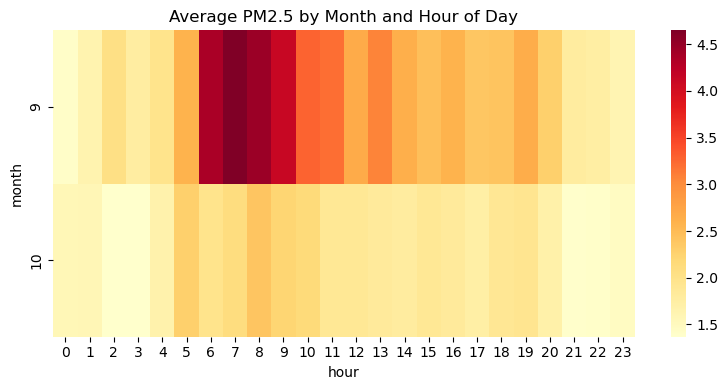

hour     0     1     2     3     4     5     6     7     8     9   ...    14  \
month                                                              ...         
9      1.41  1.64  2.04  1.77  1.97  2.59  4.36  4.65  4.47  4.13  ...  2.63   
10     1.56  1.57  1.37  1.38  1.66  2.28  1.98  2.11  2.40  2.22  ...  1.80   

hour     15    16    17    18    19    20    21    22    23  
month                                                        
9      2.46  2.60  2.38  2.41  2.65  2.29  1.80  1.76  1.62  
10     1.89  1.84  1.74  1.90  1.93  1.70  1.38  1.41  1.46  

[2 rows x 24 columns]


In [42]:
pivot = merged_df.pivot_table(
    values="pm25", 
    index="month", 
    columns="hour", 
    aggfunc="mean"
)

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, cmap="YlOrRd", fmt=".1f")
plt.title("Average PM2.5 by Month and Hour of Day")
plt.tight_layout()
plt.savefig("pm25_pivot_heatmap.png")
plt.show()
print(pivot.round(2))

**Plot 6 - Pivot Table Heatmap:** September recorded significantly higher PM2.5 levels than October, particularly during morning hours (6am–10am) where values may exceeded 4.5 µg/m³ on the other hand October shows a much more lower pattern throughout the day. This may indicate the change of season as spring progresses.

Cross-tabulation: Month vs PM2.5 Level
pm25_level  Very Low  Low  Moderate  Elevated
month                                        
9                 79   93        94        72
10               216  146       132        69


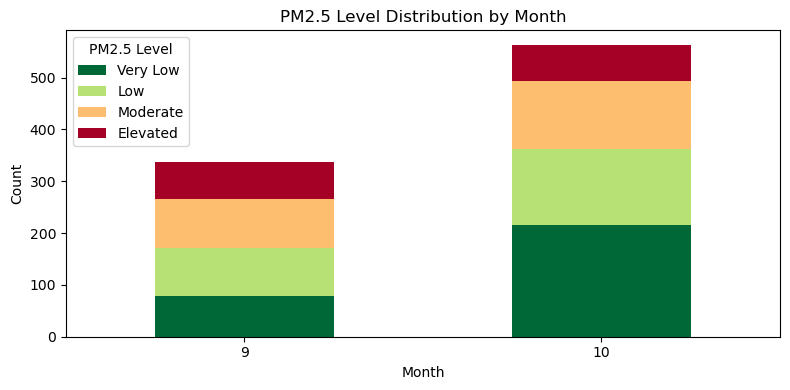

In [43]:
# Cross-tabulation: PM2.5 level category vs Month
merged_df['pm25_level'] = pd.cut(merged_df['pm25'],
                                  bins=[0, 1, 2, 4, 7],
                                  labels=['Very Low', 'Low', 'Moderate', 'Elevated'])

cross_tab = pd.crosstab(merged_df['month'], merged_df['pm25_level'])
print('Cross-tabulation: Month vs PM2.5 Level')
print(cross_tab)

cross_tab.plot(kind='bar', stacked=True, figsize=(8, 4), colormap='RdYlGn_r')
plt.title('PM2.5 Level Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='PM2.5 Level')
plt.tight_layout()
plt.show()

**Plot 7 - Cross-tabulation:** September got a higher proportion of 'Moderate' and 'Elevated' PM2.5 readings compared to October. This confirms the seasonal trend identified in the plot 6. On the contrary, October shows more readings in the 'Very Low' and 'Low' categories, suggesting improving air quality as spring advances.

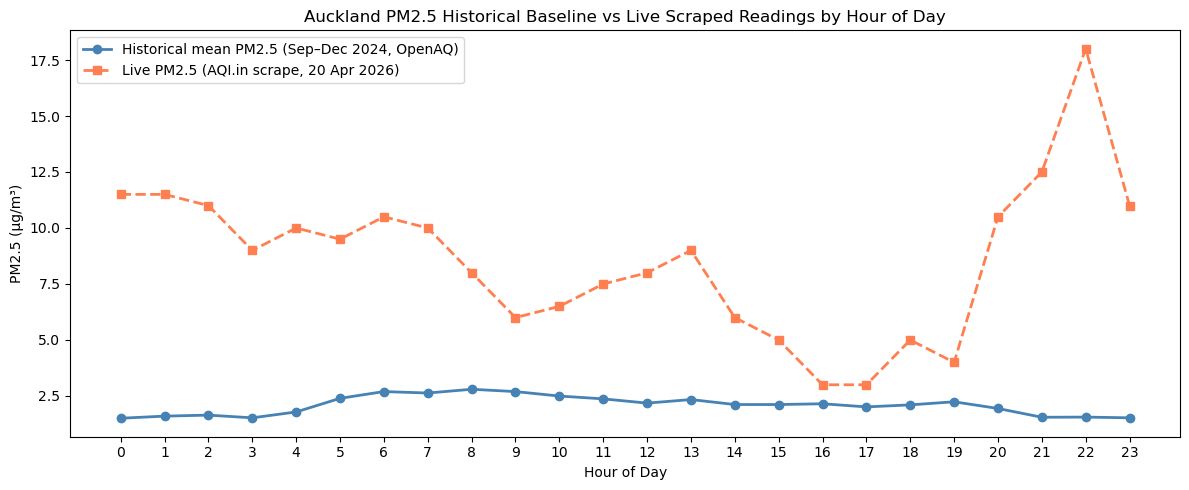

In [44]:
# Scraped AQI.in readings vs historical hourly average
historical_hourly = merged_df.groupby('hour')['pm25'].mean()

# Aligning scraped data by hour
scraped_hourly = scraped_df.groupby('hour')['pm25_scraped'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(historical_hourly.index, historical_hourly.values,
        marker='o', color='steelblue', linewidth=2, label='Historical mean PM2.5 (Sep–Dec 2024, OpenAQ)')
ax.plot(scraped_hourly.index, scraped_hourly.values,
        marker='s', color='coral', linewidth=2, linestyle='--', label='Live PM2.5 (AQI.in scrape, 20 Apr 2026)')
ax.set_title('Auckland PM2.5 Historical Baseline vs Live Scraped Readings by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

**Plot 8 - Scraped vs Historical Comparison:** This plot directly integrates the two main data sources. The live AQI.in readings (April 2026) are notably higher than the merged Sep–Dec 2024 historical dataset.The diurnal shape is broadly similar in both datasets, with higher morning values, validating the robustness of the morning traffic PM2.5 peak also identified in the merged historical data.

In [45]:
#dropping the bin column before modleing
merged_df = merged_df.drop(columns=['pm25_level'])
print('Ready for modelling. Shape:', merged_df.shape)

Ready for modelling. Shape: (905, 11)


# Predictive Modelling <a id="predictive-modelling"></a>

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features (X) and Target (y)
features = ["temperature", "humidity", "wind_speed", "pressure", "precipitation", "hour", "month"]
target = "pm25"

X = merged_df[features]
y = merged_df[target]

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (724, 7)
Test set size: (181, 7)


In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled")

Features scaled


In [48]:
# Model evaluation helper function
results = {}

def evaluate_model(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {"RMSE": rmse, "R2": r2}
    print(f"{name}: RMSE={rmse:.4f} | R²={r2:.4f}")
    return rmse, r2

### Simple Linear Regression

In [49]:
#Model 1 : Simple linear regression
from sklearn.linear_model import LinearRegression

# Using temperature as single predictor
simple_lr = LinearRegression()
simple_lr.fit(X_train[["temperature"]], y_train)
y_pred_simple = simple_lr.predict(X_test[["temperature"]])

evaluate_model("Simple Linear Regression (temperature)", y_test, y_pred_simple)
print(f"Coefficient: {simple_lr.coef_[0]:.4f} | Intercept: {simple_lr.intercept_:.4f}")

Simple Linear Regression (temperature): RMSE=1.7892 | R²=-0.0280
Coefficient: 0.1465 | Intercept: -0.0456


### Multiple Linear Regression

In [50]:
#model 2 : Multiple Lineral Regression (All Feature)
multi_lr = LinearRegression()
multi_lr.fit(X_train, y_train)
y_pred_multi = multi_lr.predict(X_test)

evaluate_model("Multiple Linear Regression", y_test, y_pred_multi)

# Show feature importance
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": multi_lr.coef_
}).sort_values("Coefficient", ascending=False)
print(coef_df)

Multiple Linear Regression: RMSE=1.7366 | R²=0.0316
         Feature  Coefficient
0    temperature     0.242507
1       humidity     0.036031
2     wind_speed     0.017716
3       pressure    -0.003480
5           hour    -0.015191
4  precipitation    -0.437071
6          month    -0.963638


**Feature Coefficients:** Temperature has the largest positive coefficient (0.24), meaning a 1°C increase in temperature is associated with a 0.24 µg/m³ increase in PM2.5.

### Polynomial Linear Regression

In [51]:
# Model 3: Polynomial Regression (degrees 2 and 3)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

for degree in [2, 3]:
    poly_model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("linear", LinearRegression())
    ])
    poly_model.fit(X_train, y_train)
    y_pred_poly = poly_model.predict(X_test)
    evaluate_model(f"Polynomial Regression (degree={degree})", y_test, y_pred_poly)

Polynomial Regression (degree=2): RMSE=3.2397 | R²=-2.3703
Polynomial Regression (degree=3): RMSE=9.6657 | R²=-29.0006


**Polynomial Regression:** Degree 2 produced RMSE=3.24 (R²=-2.37) and degree 3 produced RMSE=9.67 (R²=-29.0). Both are dramatically worse than linear regression. A negative R² means the model performs worse than simply predicting the mean.

### kNN Regression (Euclidean distance)

In [52]:
# Model 4: kNN Regression (Euclidean distance)
from sklearn.neighbors import KNeighborsRegressor

for k in [3, 5, 10, 15]:
    knn = KNeighborsRegressor(n_neighbors=k, metric="euclidean")
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    evaluate_model(f"kNN (k={k}, euclidean)", y_test, y_pred_knn)

kNN (k=3, euclidean): RMSE=1.3523 | R²=0.4128
kNN (k=5, euclidean): RMSE=1.4159 | R²=0.3563
kNN (k=10, euclidean): RMSE=1.5268 | R²=0.2515
kNN (k=15, euclidean): RMSE=1.5332 | R²=0.2451


### kNN Regression (Manhattan distance)

In [53]:
# Model 5: kNN Regression (Manhattan distance)
for k in [3, 5, 10, 15]:
    knn = KNeighborsRegressor(n_neighbors=k, metric='manhattan')
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    evaluate_model(f'kNN (k={k}, manhattan)', y_test, y_pred_knn)

kNN (k=3, manhattan): RMSE=1.2660 | R²=0.4853
kNN (k=5, manhattan): RMSE=1.3891 | R²=0.3803
kNN (k=10, manhattan): RMSE=1.5166 | R²=0.2614
kNN (k=15, manhattan): RMSE=1.5336 | R²=0.2447


**kNN Distance Metric Comparison:** Manhattan distance outperformed Euclidean across all values of k. The best model overall was kNN (k=3, manhattan) with RMSE=1.27 and R²=0.49.

In [54]:
# Full model comparison table
results_df = pd.DataFrame(results).T.sort_values('RMSE')
print(results_df.round(4))

                                          RMSE       R2
kNN (k=3, manhattan)                    1.2660   0.4853
kNN (k=3, euclidean)                    1.3523   0.4128
kNN (k=5, manhattan)                    1.3891   0.3803
kNN (k=5, euclidean)                    1.4159   0.3563
kNN (k=10, manhattan)                   1.5166   0.2614
kNN (k=10, euclidean)                   1.5268   0.2515
kNN (k=15, euclidean)                   1.5332   0.2451
kNN (k=15, manhattan)                   1.5336   0.2447
Multiple Linear Regression              1.7366   0.0316
Simple Linear Regression (temperature)  1.7892  -0.0280
Polynomial Regression (degree=2)        3.2397  -2.3703
Polynomial Regression (degree=3)        9.6657 -29.0006


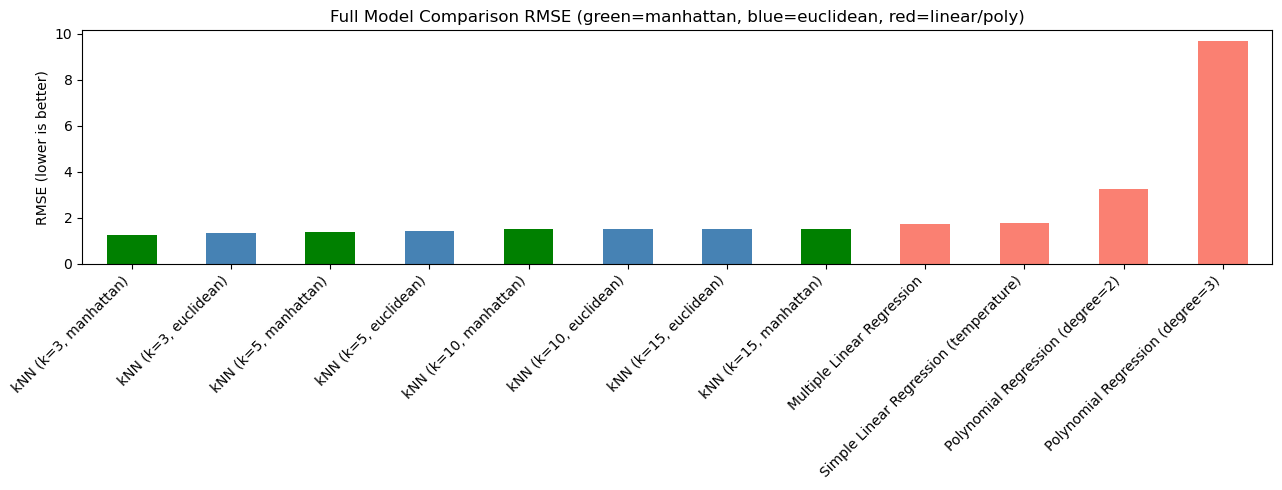

In [55]:
# Comparison bar chart
plt.figure(figsize=(13, 5))
colors = ['green' if 'manhattan' in i else 'steelblue' if 'euclidean' in i else 'salmon' for i in results_df.index]
results_df['RMSE'].plot(kind='bar', color=colors)
plt.title('Full Model Comparison RMSE (green=manhattan, blue=euclidean, red=linear/poly)')
plt.ylabel('RMSE (lower is better)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('full_model_comparison.png')
plt.show()

**Comparison Between all the models:** kNN models outperformed all linear models**, with kNN (k=3, Manhattan) 
achieving the best overall performance (RMSE=1.27, R²=0.49). This suggests 
that PM2.5 concentration in Auckland has non-linear relationships with weather 
variables that kNN captures better through local neighbourhood similarity 
rather than a global equation.

In [56]:
# Cross-validation on best model (kNN k=3 manhattan)
from sklearn.model_selection import train_test_split, cross_val_score

best_knn_cv = KNeighborsRegressor(n_neighbors=3, metric='manhattan')
cv_scores = cross_val_score(best_knn_cv, X_train_scaled, y_train, cv=5, scoring='r2')

print('5-Fold Cross-Validation Results (kNN k=3, manhattan):')
print('R² per fold:', cv_scores.round(4))
print(f'Mean R²: {cv_scores.mean():.4f}')
print(f'Std R²: {cv_scores.std():.4f}')

5-Fold Cross-Validation Results (kNN k=3, manhattan):
R² per fold: [0.4825 0.2327 0.529  0.4964 0.3108]
Mean R²: 0.4103
Std R²: 0.1168


5-fold cross-validation on the best model (kNN k=3, Manhattan) was used to 
verify that the model generalises beyond its training data. A consistent R² 
across all five folds confirms the model is not overfitting to a specific 
subset of the data.

In [57]:
# Bootstrap confidence intervals for best model (kNN k=3, manhattan)
from sklearn.utils import resample

best_knn = KNeighborsRegressor(n_neighbors=3, metric='manhattan')
best_knn.fit(X_train_scaled, y_train)

n_bootstraps = 1000
bootstrap_preds = []

for i in range(n_bootstraps):
    X_bs, y_bs = resample(X_train_scaled, y_train, random_state=i)
    best_knn.fit(X_bs, y_bs)
    bootstrap_preds.append(best_knn.predict(X_test_scaled))

bootstrap_preds = np.array(bootstrap_preds)
lower = np.percentile(bootstrap_preds, 2.5, axis=0)
upper = np.percentile(bootstrap_preds, 97.5, axis=0)
mean_pred = np.mean(bootstrap_preds, axis=0)

print(f'Average 95% prediction interval width: {np.mean(upper - lower):.4f} µg/m³')

Average 95% prediction interval width: 2.2178 µg/m³


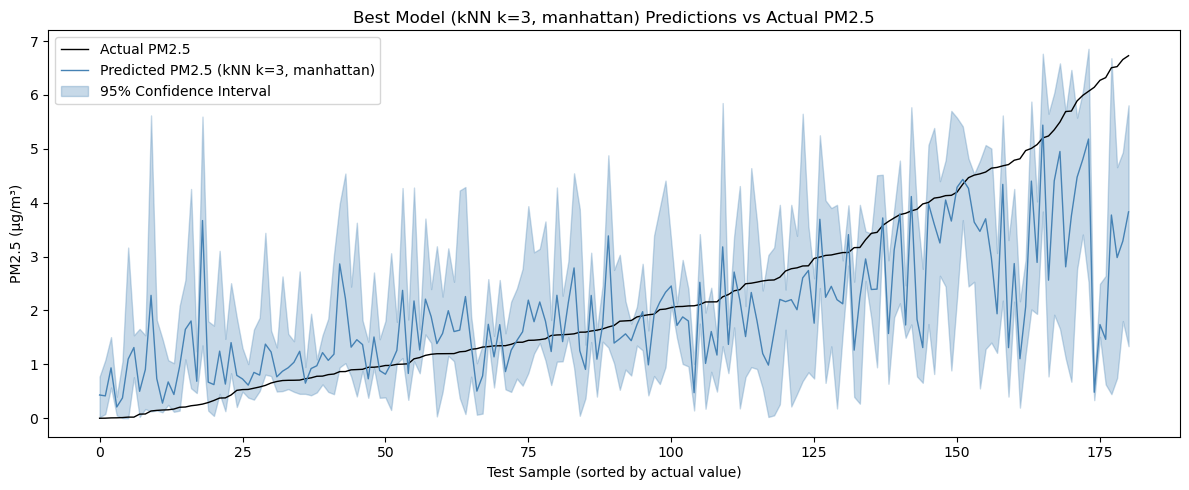

In [58]:
# Plotting predictions vs actual with confidence band
sorted_idx = np.argsort(y_test.values)
y_test_sorted = y_test.values[sorted_idx]
mean_sorted = mean_pred[sorted_idx]
lower_sorted = lower[sorted_idx]
upper_sorted = upper[sorted_idx]

plt.figure(figsize=(12, 5))
plt.plot(y_test_sorted, label='Actual PM2.5', color='black', linewidth=1)
plt.plot(mean_sorted, label='Predicted PM2.5 (kNN k=3, manhattan)', color='steelblue', linewidth=1)
plt.fill_between(range(len(y_test_sorted)), lower_sorted, upper_sorted,
                 alpha=0.3, color='steelblue', label='95% Confidence Interval')
plt.title('Best Model (kNN k=3, manhattan) Predictions vs Actual PM2.5')
plt.xlabel('Test Sample (sorted by actual value)')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.tight_layout()
plt.savefig('knn_confidence_interval.png')
plt.show()

**Confidence Interval -Interpretation:** The 95% bootstrap confidence interval has an average width of ~2.2 µg/m³. The model tracks the general upward trend in actual PM2.5 values well in the 0–3 µg/m³ range, but struggles with high-value spikes above 4 µg/m³.

# Conclusion 
This project predicted Auckland PM2.5 levels using weather features, with kNN (k=3, Manhattan) emerging as the best model (RMSE=1.27, R²=0.49) where the weather variables alone explain 49% of PM2.5 variance.

### Key findings:

1. A clear morning peak in PM2.5 (6–10am) aligns with Auckland's rush hour, identifying traffic emissions as the pollution driver.
2. Temperature is the strongest weather predictor of PM2.5 (r=0.17, coefficient=0.24)
3. kNN with Manhattan distance significantly outperformed all linear models

# Bibliography (optional) 